# Análise Exploratória Orientada a Negócio — Bank Customer Churn

**Objetivo deste notebook:** responder às perguntas de negócio definidas para este projeto — quem cancela, por quê, e quanto isso custa em receita — usando o dataset já tratado (`data/processed/churn_clean.csv`).

**O que este notebook NÃO faz:** tratamento de dados (já feito em `01_data_cleaning.ipynb`) e modelagem preditiva (fica para `03_modelagem.ipynb`). Aqui é só entender o problema antes de automatizar a resposta.

**Perguntas de negócio que este notebook responde:**
1. Qual é a taxa de churn e o que isso já custou em saldo perdido?
2. Existe um perfil (ocupação, patrimônio, tempo de relacionamento) mais propenso a cancelar?
3. O comportamento financeiro recente prevê cancelamento?
4. Quanto vale, em receita, priorizar os clientes ativos de maior risco?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv(r"C:\Users\engpe\OneDrive\Documentos\Portfólio\bank-churn-prediction-dashboard\data\processed\churn_clean.csv", parse_dates=['last_transaction'])
df.shape

(28382, 22)

## 1. Taxa de churn geral


Taxa de churn: 18.53%
Clientes que cancelaram: 5,260
Clientes ativos: 23,122


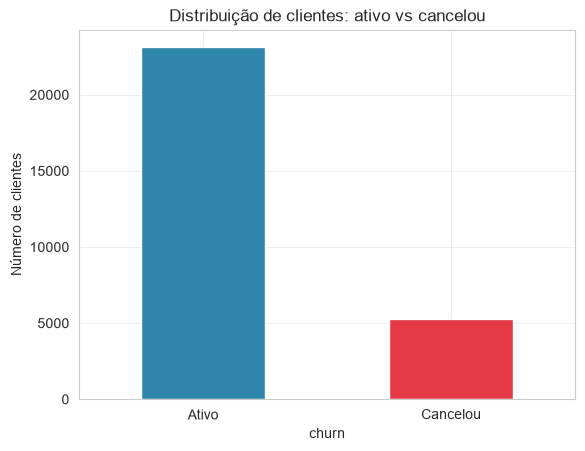

In [3]:
taxa_churn = df['churn'].mean()
print(f"Taxa de churn: {taxa_churn*100:.2f}%")
print(f"Clientes que cancelaram: {df['churn'].sum():,}")
print(f"Clientes ativos: {(df['churn']==0).sum():,}")

df['churn'].value_counts().plot(kind='bar', color=['#2E86AB', '#E63946'])
plt.xticks([0,1], ['Ativo', 'Cancelou'], rotation=0)
plt.title('Distribuição de clientes: ativo vs cancelou')
plt.ylabel('Número de clientes')
plt.show()

**Leitura:** ~18,5% de churn é uma taxa alta pra um banco (setor bancário tradicionalmente tem churn anual bem menor). Isso já justifica, de cara, um projeto de retenção — e confirma que o desbalanceamento (82% / 18%) é realista, não um problema criado artificialmente pelo dataset.

## 2. Quanto já foi perdido em saldo?

In [12]:
saldo_total = df['current_balance'].sum()
saldo_perdido = df.loc[df['churn']==1, 'current_balance'].sum()
pct_perdido = saldo_perdido / saldo_total * 100

print(f"Saldo total na base: {saldo_total:,.2f}")
print(f"Saldo em contas que já cancelaram: {saldo_perdido:,.2f}")
print(f"Isso representa {pct_perdido:.1f}% de todo o saldo da base")

Saldo total na base: 209,474,821.29
Saldo em contas que já cancelaram: 27,461,851.53
Isso representa 13.1% de todo o saldo da base


**Este é o número-chave do projeto:** o banco já perdeu 27,4 milhões em saldo de clientes que cancelaram — 13,1% de todo o saldo administrado na base. É essa cifra que justifica investir em um modelo preditivo: cada ponto percentual de churn evitado vale, em média, mais de 1,5 milhão em saldo retido.

## 3. Existe um perfil de quem cancela?

In [5]:
perfil = df.groupby('churn').agg(
    idade_media=('age', 'mean'),
    vintage_medio=('vintage', 'mean'),
    dependentes_medio=('dependents', 'mean'),
).round(1)
perfil.index = ['Ativo', 'Cancelou']
perfil

,idade_media,vintage_medio,dependentes_medio
Ativo,48.4,2091.8,0.3
Cancelou,47.5,2088.4,0.4


**Leitura:** idade, tempo de relacionamento (vintage) e número de dependentes são **quase idênticos** entre quem fica e quem cancela. Ou seja: perfil demográfico sozinho não explica o churn aqui — é preciso olhar para comportamento financeiro (próxima seção), não só quem o cliente é.

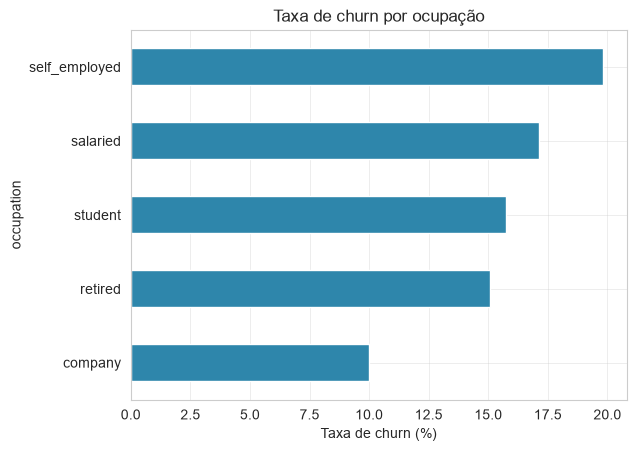

occupation
self_employed    19.8
salaried         17.1
student          15.7
retired          15.1
company          10.0
Name: churn, dtype: float64

In [6]:
churn_por_ocupacao = df.groupby('occupation', observed=True)['churn'].mean().sort_values(ascending=False) * 100

churn_por_ocupacao.plot(kind='barh', color='#2E86AB')
plt.xlabel('Taxa de churn (%)')
plt.title('Taxa de churn por ocupação')
plt.gca().invert_yaxis()
plt.show()

churn_por_ocupacao.round(1)

**Leitura:** clientes `self_employed` (autônomos) cancelam quase o dobro dos clientes `company` (funcionários de empresa) — 19,8% vs 10,0%. Faz sentido de negócio: renda de autônomo é mais instável, então a relação com o banco tende a ser mais oportunista. Isso já é um critério útil de priorização para a equipe de retenção.

## 4. O comportamento financeiro recente é o sinal mais forte

In [7]:
comportamento = df.groupby('churn')[['current_balance', 'average_monthly_balance_prevQ']].mean()
comportamento.index = ['Ativo', 'Cancelou']
comportamento.round(2)

,current_balance,average_monthly_balance_prevQ
Ativo,7871.85,7258.75
Cancelou,5220.88,8543.09


Aqui está o achado mais importante do notebook: clientes que **cancelaram tinham, em média, saldo médio no trimestre anterior MAIOR** (8.543) que os clientes ativos (7.259) — mas o **saldo atual deles é bem menor** (5.221 vs 7.872).

Ou seja: **não é que o cliente que cancela já era "pequeno"** — ele estava indo embora aos poucos, esvaziando a conta antes de fechar de vez. Isso vira uma feature nova, muito mais poderosa que o saldo isolado:

Ativo       -613.10
Cancelou    3322.21
Name: queda_saldo, dtype: float64


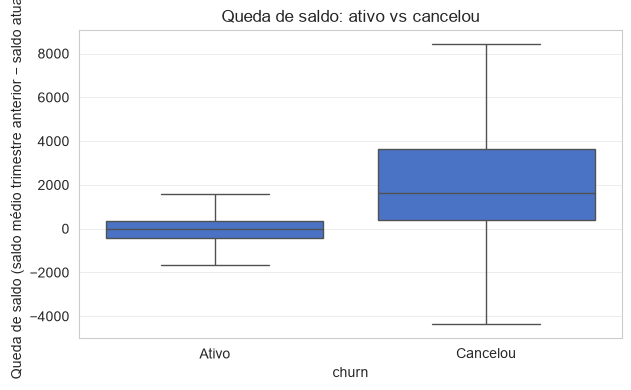

In [8]:
df['queda_saldo'] = df['average_monthly_balance_prevQ'] - df['current_balance']

queda_por_grupo = df.groupby('churn')['queda_saldo'].mean()
queda_por_grupo.index = ['Ativo', 'Cancelou']
print(queda_por_grupo.round(2))

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='churn', y='queda_saldo', showfliers=False)
plt.xticks([0,1], ['Ativo', 'Cancelou'])
plt.ylabel('Queda de saldo (saldo médio trimestre anterior − saldo atual)')
plt.title('Queda de saldo: ativo vs cancelou')
plt.show()

**Leitura:** clientes ativos, em média, tiveram uma **variação de 613** (ou seja, o saldo cresceu levemente) enquanto quem cancelou teve uma **queda média de 3.322**. Essa é, disparado, a feature mais promissora para o modelo — muito mais informativa que idade, ocupação ou tempo de relacionamento.

**Implicação prática:** a equipe de retenção não precisa esperar o cliente cancelar — uma queda de saldo consistente ao longo de um trimestre já é um alerta acionável hoje.

## 5. Dois sinais adicionais (com ressalvas)

In [9]:
neg = df.groupby('saldo_negativo')['churn'].mean() * 100
print("Taxa de churn por saldo negativo:")
print(neg.round(1))
print()
print("Tamanho de cada grupo:")
print(df['saldo_negativo'].value_counts())

Taxa de churn por saldo negativo:
saldo_negativo
0    18.5
1    82.4
Name: churn, dtype: float64

Tamanho de cada grupo:
saldo_negativo
0    28365
1       17
Name: count, dtype: int64


**Saldo negativo:** clientes com saldo atual negativo cancelam em 82,4% dos casos, contra 18,5% dos demais — parece um sinal fortíssimo. **Ressalva importante:** só existem 17 clientes nessa condição em toda a base. É um sinal real, mas raro demais para carregar o modelo sozinho.

In [10]:
df['sem_transacao_recente'] = df['last_transaction'].isnull().astype(int)
sem_transacao = df.groupby('sem_transacao_recente')['churn'].mean() * 100
print(sem_transacao.round(1))

sem_transacao_recente
0    19.7
1     9.3
Name: churn, dtype: float64


**Ausência de última transação registrada:** aqui o resultado é **contraintuitivo** — quem não tem transação registrada cancela MENOS (9,3%) do que quem tem (19,7%). A hipótese inicial (sem transação = sinal de abandono) não se confirma. Provável explicação: a ausência de registro pode ser uma característica de contas mais antigas/dormentes de outro tipo, não de quem está saindo ativamente.

## 6. Priorização: onde focar a retenção

In [11]:
ativos = df[df['churn']==0]
p90 = ativos['current_balance'].quantile(0.9)
alto_valor = ativos[ativos['current_balance'] >= p90]

print(f"Clientes ativos de alto valor (top 10% por saldo): {len(alto_valor):,}")
print(f"Saldo total desse grupo: R$ {alto_valor['current_balance'].sum():,.2f}")
print(f"Isso é {alto_valor['current_balance'].sum() / ativos['current_balance'].sum() * 100:.1f}% de todo o saldo ativo da base")

Clientes ativos de alto valor (top 10% por saldo): 2,313
Saldo total desse grupo: R$ 94,122,055.52
Isso é 51.7% de todo o saldo ativo da base


**Leitura final:** os 2.313 clientes ativos de maior saldo (top 10%) concentram uma fatia desproporcional do saldo total ativo. Cruzando isso com a feature de queda de saldo (seção 4), dá pra construir uma lista de prioridade de retenção: **cliente de alto valor + queda de saldo consistente = ação imediata**. Essa combinação vai virar a lógica da aba "Simulador" do dashboard.

---
## Resumo de insights (para o README)

| Pergunta | Resposta |
|---|---|
| Taxa de churn | 18,5% |
| Receita já perdida | R\$ 27,4 milhões (13,1% do saldo total da base) |
| Perfil demográfico prevê churn? | Não — idade, vintage e dependentes são quase iguais entre os grupos |
| Ocupação importa? | Sim — autônomos cancelam quase 2x mais que funcionários de empresa (19,8% vs 10,0%) |
| Sinal mais forte | Queda de saldo no trimestre (média R\$ 3.322 entre quem cancela vs -R\$ 613 entre quem fica) |
| Sinal contraintuitivo | Ausência de transação recente NÃO indica maior churn — o oposto acontece |
| Onde priorizar | Cruzar clientes de alto saldo (top 10%) com sinal de queda de saldo |

**Próximo notebook:** `03_modelagem.ipynb`.